In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [3]:
df=pd.read_csv(r'Datasets\Ice_cream selling data.csv')

In [4]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


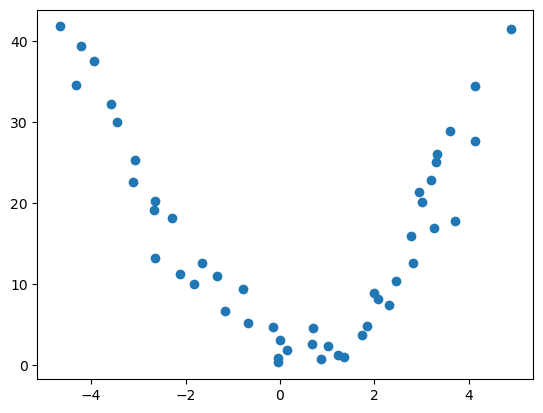

In [5]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

In [6]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [7]:
X = df[['Temperature (°C)']]
y =  df['Ice Cream Sales (units)']

## Train Test Split

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [9]:
ytrain

12    11.218294
4     32.284531
34     7.412094
8     19.226970
3     37.539845
6     22.635401
40    22.839406
41    16.983279
46    34.530743
15    10.957731
9     20.279679
16     6.689123
24     2.576782
33     8.170735
30     3.782570
0     41.842986
43    26.104740
32     8.943823
5     30.001138
29     0.953115
11    18.123991
36    15.996620
1     34.661120
21     0.897603
2     39.383001
37    12.568237
35    10.336631
23     1.931416
39    20.114413
10    13.275828
22     3.165600
18     5.210163
48    41.514822
20     0.328626
7     25.365022
42    25.142082
14    12.615181
28     1.292361
38    21.342916
Name: Ice Cream Sales (units), dtype: float64

In [10]:
xtrain.head()

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661


## Creating some more features with linear regression

In [ ]:
poly=PolynomialFeatures(degree=2)
# When we increase the degree , Model get more complex which capture noise pattern ,mamorize the pattern and lead to overfit.

In [12]:
xtrainpoly=poly.fit_transform(xtrain)

In [13]:
xtestpoly=poly.transform(xtest)


In [14]:
xtrainpoly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

# Ploynomial Regression Model Based

### Now we pass polynomial features to linear model(LinearRegression) , So that LinearRegression model capture non linear data points.

In [15]:
PolyModel=LinearRegression()

In [16]:
PolyModel.fit(xtrainpoly, ytrain)

LinearRegression()

In [17]:
xtrainpolypred=PolyModel.predict(xtrainpoly)


In [18]:
xtestpolypred = PolyModel.predict(xtestpoly)

In [19]:
train_score=r2_score(ytrain,xtrainpolypred)#ytrain is a actual output for train data
test_score=r2_score(ytest,xtestpolypred) #ytest is a actual output for test data
print(f'Train Score : => {train_score}\nTest Score : => {test_score}')

Train Score : => 0.9413665676490518
Test Score : => 0.8430551371938843


## Scatter Plot For Better Understanding

#### TRAIN ACTUAL VS POLYPREDICTED

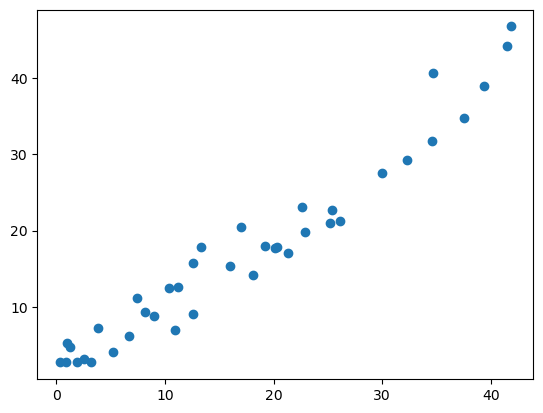

In [20]:
plt.scatter(ytrain,xtrainpolypred)

### ACTUAL TRAIN POINT VS PREDICTED POINT

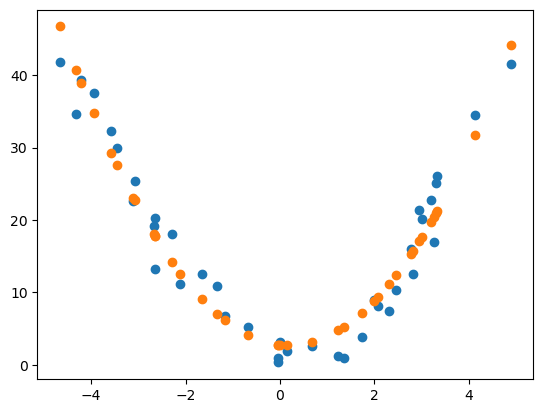

In [28]:
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,xtrainpolypred)

#### TEST ACTUAL VS POLYPREDICTED

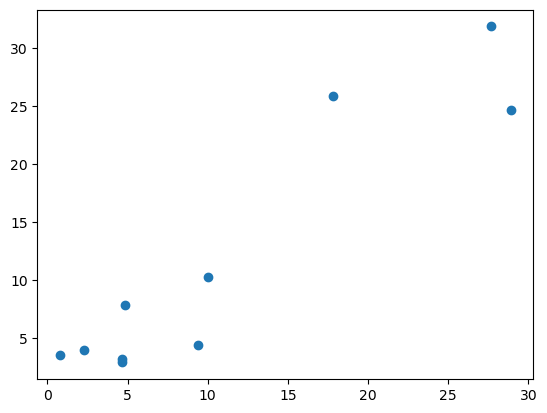

In [21]:
plt.scatter(ytest,xtestpolypred)

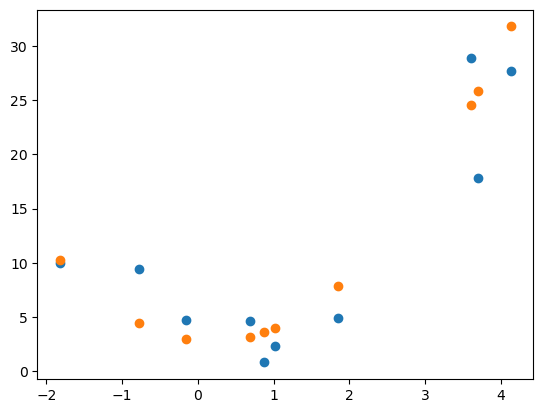

In [29]:
plt.scatter(xtest,ytest)
plt.scatter(xtest,xtestpolypred)

# Linear Model  Based

In [31]:
LinearModel=LinearRegression()

In [32]:
LinearModel.fit(xtrain, ytrain)

LinearRegression()

In [33]:
xtrainpred=LinearModel.predict(xtrain)

In [34]:
test_score = LinearModel.score(xtest,ytest)
train_score = LinearModel.score(xtrain,ytrain)
print(f'Train Score : => {train_score}\nTest Score : => {test_score}')

Train Score : => 0.06579063815950037
Test Score : => -0.5751270190188227


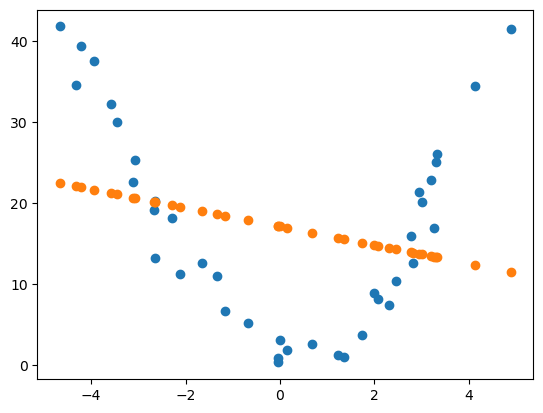

In [35]:
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,xtrainpred)